In [ ]:
# Data collection command:
# `python comet_download.py --project=ns-target-summation --n_threads=8`
# `python comet_download.py --project=ns-input-summation --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [12]:
save_path = 'figures/'

input_config_dfs, input_run_dfs = load_experiment_data(
    'data/ns-input-summation_params.csv',
    'data/ns-input-summation_metrics.csv',
)
target_config_dfs, target_run_dfs = load_experiment_data(
    'data/ns-target-summation_params.csv',
    'data/ns-target-summation_metrics.csv',
)

del target_config_dfs[np.nan], target_run_dfs[np.nan]

# config_dfs = {**{f"input_{k}": v for k, v in input_config_dfs.items()}, **{f"target_{k}": v for k, v in target_config_dfs.items()}}
# run_dfs = {**{f"input_{k}": v for k, v in input_run_dfs.items()}, **{f"target_{k}": v for k, v in target_run_dfs.items()}}

# # del config_dfs['input_nan'], run_dfs['input_nan']
# del config_dfs['target_nan'], run_dfs['target_nan']

print('Targets:')
print({k: len(v) for k, v in target_config_dfs.items()})

print('Inputs:')
print({k: len(v) for k, v in input_config_dfs.items()})

Targets:
{'sgd': 40, 'sgd_split_step_size': 244, 'autostep': 210, 'upgd': 1500}
Inputs:
{'upgd': 1500, 'sgd': 40, 'sgd_split_step_size': 245, 'autostep': 210}


In [13]:
print("_____Best Hyperparameter Configurations | TARGETS_____")
best_target_config_dfs, best_target_run_dfs, best_var_vals = get_best_ablation_values(
    target_config_dfs, target_run_dfs) #, sweep_ablation_vars, sweep_split_vars)

print("_____Best Hyperparameter Configurations | INPUTS_____")
best_input_config_dfs, best_input_run_dfs, best_var_vals = get_best_ablation_values(
    input_config_dfs, input_run_dfs) #, sweep_ablation_vars, sweep_split_vars)

_____Best Hyperparameter Configurations | TARGETS_____

=== sgd ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-5


=== sgd_split_step_size ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-7
  Best representation_optimizer|learning_rate=2**-3


=== autostep ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-11
  Best optimizer|meta_learning_rate=2**-4


=== upgd ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-9
  Best optimizer|weight_decay=0.001
  Best optimizer|beta_utility=0.0
  Best optimizer|sigma=0.1

_____Best Hyperparameter Configurations | INPUTS_____

=== upgd ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-6
  Best optimizer|weight_decay=0.001
  Best optimizer|beta_utility=0.9
  Best optimizer|sigma=0.0001


=== sgd ===

Configuration: (no split vars) | # runs: 5
  Best optimizer|learning_rate=2**-5


=== s

In [14]:
print("_____Best Hyperparameter Configurations_____")
# sweep_ablation_vars = {
#     # 'change_type': ['task|input_change_freq', 'task|max_input_center_change'],
#     # 'change_type_given_features': ['task|input_change_freq', 'task|max_input_center_change'],
#     'autostep': ['optimizer|meta_learning_rate'],
#     'sgd': ['optimizer|learning_rate'],
#     'sgd_split_step_size': ['optimizer|learning_rate', 'representation_optimizer|learning_rate'],
# }
# sweep_split_vars = {
#     'autostep': ['model|use_perfect_features'],
#     'sgd': ['model|use_perfect_features'],
#     'sgd_split_step_size': ['model|use_perfect_features'],
# }


# best_config_dfs, best_run_dfs, best_var_vals = get_best_ablation_values(
#     config_dfs, run_dfs) #, sweep_ablation_vars, sweep_split_vars)

_____Best Hyperparameter Configurations_____


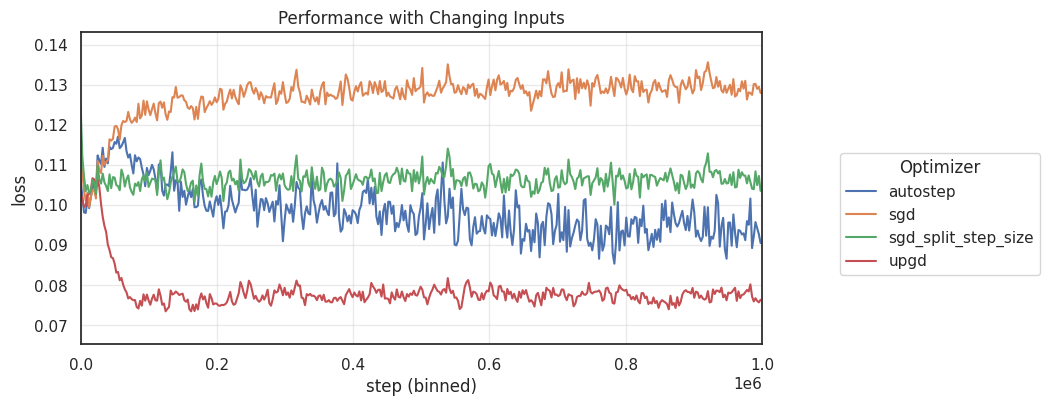

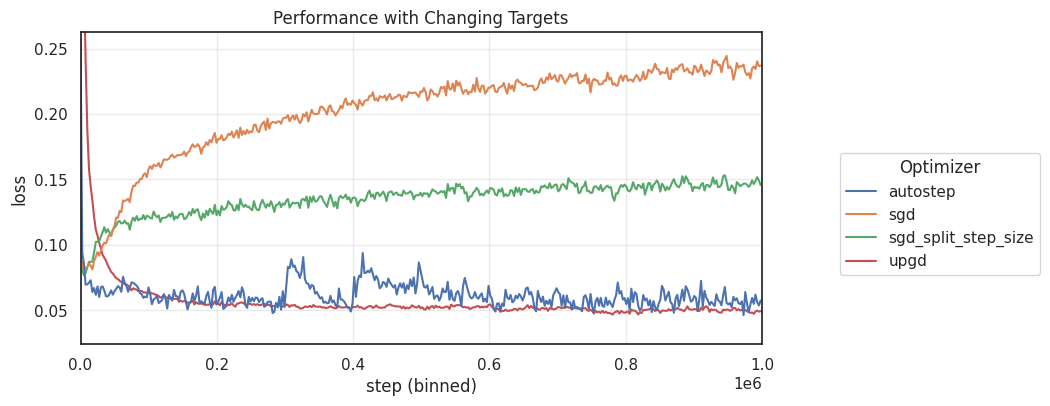

In [19]:
plot_run_df = pd.concat(best_input_run_dfs.values())
plot_config_df = pd.concat(best_input_config_dfs.values())

plot_learning_curves(
    run_df = plot_run_df,
    config_df = plot_config_df,
    n_bins = 400,
    figsize = (8, 4),
    hue_col = 'sweep_name',
    legend_title = 'Optimizer',
)
plt.title('Performance with Changing Inputs')
plt.show()

plot_run_df = pd.concat(best_target_run_dfs.values())
plot_config_df = pd.concat(best_target_config_dfs.values())

plot_learning_curves(
    run_df = plot_run_df,
    config_df = plot_config_df,
    n_bins = 400,
    figsize = (8, 4),
    hue_col = 'sweep_name',
    legend_title = 'Optimizer',
)
plt.title('Performance with Changing Targets')
plt.show()